In [1]:

from cellmates.utils.tree_utils import convert_skbio_to_networkx, newick_to_nx, convert_networkx_to_dendropy, \
    normalized_rf_distance, relabel_name_to_int
%load_ext autoreload
%autoreload 2
import os
import pandas as pd
import dendropy
import numpy as np
import networkx as nx
import anndata
import scgenome.plotting as pl
from Bio import Phylo
from cellmates.utils.tree_utils import  nxtree_to_newick
from cellmates.common_helpers.cnasim_data import profiles_to_anndata

/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/scgenome/refgenome.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
adata = profiles_to_anndata("/home/vittorio.zampinetti/data/noisy_simul_cn_dice.tsv", 'state')
adata

AnnData object with n_obs × n_vars = 20 × 500
    var: 'chr', 'start', 'end'
    layers: 'state', 'stateA', 'stateB'

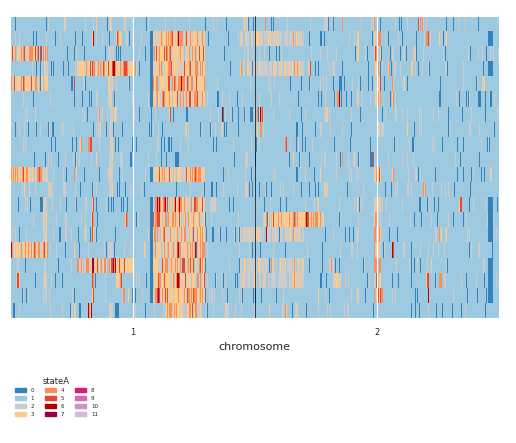

In [3]:
pl.plot_cell_cn_matrix_fig(adata, layer_name='stateA');

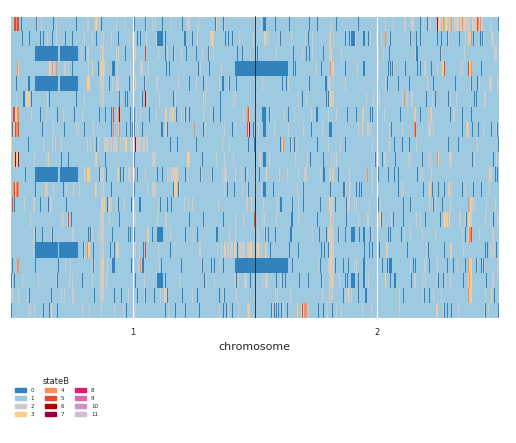

In [4]:
pl.plot_cell_cn_matrix_fig(adata, layer_name='stateB');

In [5]:
# make an anndata with concatenated profiles where chr is 1A and 1B
chr_df = adata.var[['chr', 'start', 'end']].reset_index()
n_bins = chr_df.shape[0]
var_df = pd.concat([chr_df, chr_df], axis=0).reset_index(drop=True)
max_chr = var_df['chr'].astype(int).max()
var_df['chr'] = (var_df['chr'].astype(int) + ([0] * n_bins + [max_chr] * n_bins)).astype(str)
var_df['phases'] = var_df['chr'].astype(str) + (['A'] * n_bins + ['B'] * n_bins)
adata_joint = anndata.AnnData(
    X=np.concatenate([adata.layers['stateA'], adata.layers['stateB']], axis=1),
    var=var_df,
    obs=adata.obs
)
adata_joint.layers['state'] = adata_joint.X

/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


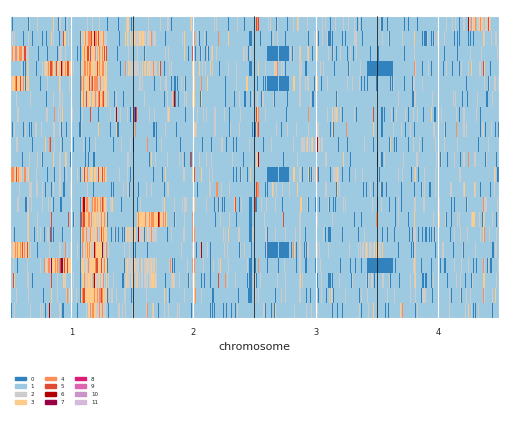

In [6]:
pl.plot_cell_cn_matrix_fig(adata_joint, layer_name=None);

In [10]:
# save this anndata joint
# adata_joint.write_h5ad("/home/vittorio.zampinetti/cellmates_res/noisy_simul/noisy_simul_cn_dice.h5ad")

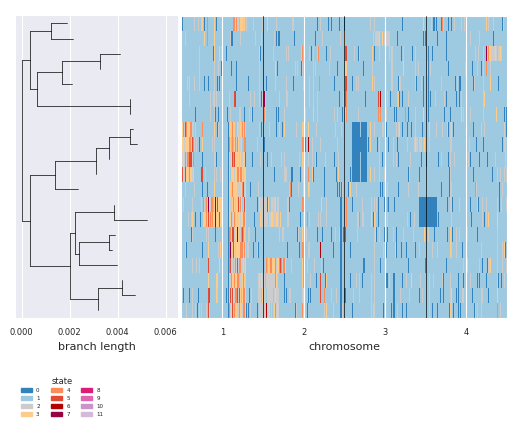

In [11]:
import io
from Bio import Phylo
# tree_path = "/home/vittorio.zampinetti/cellmates_res/noisy_simul/cm_out_cn/tree_0_3.nwk"
# tree_path = "/home/vittorio.zampinetti/cellmates_res/noisy_simul/cm_out_cn/tree_0_1.nwk"
tree_path = "/home/vittorio.zampinetti/cellmates_res/noisy_simul/N20_M500_K7_pCN0.001_pfCN0.01_CNlength0.1_err0.3_CNAsim_dseed0/cm_out_cn_05/tree.nwk"
biotree = Phylo.read(open(tree_path), 'newick')
pl.plot_cell_cn_matrix_fig(adata_joint, layer_name='state', tree=biotree);

In [12]:
true_nwk_path = "/home/vittorio.zampinetti/cellmates_res/noisy_simul/true_tree.nwk"
gt_treebio = Phylo.read(open(true_nwk_path), 'newick')
gt_treebio

Tree(rooted=False, weight=1.0)

In [13]:
print(open(true_nwk_path).read().strip())

((((11:0.0010025083446083532,(0:0.0040405414430957284,9:0.005063561576345158)34:0.003022727541705067)35:0.003022727541705067,(6:0.003022727541705067,7:0.008164398883217698)33:0.006091841476323157)36:0.0010025083446083532,(8:0.005063561576345158,19:0.0076442425432603255)32:0.005063561576345158)37:0.0010025083446083532,((((12:0.003022727541705067,18:0.007125435507904842)28:0.0020100671504982683,13:0.0020100671504982683)29:0.003022727541705067,((3:0.0010025083446083532,16:0.0020100671504982683)26:0.0040405414430957284,((1:0.003022727541705067,17:0.0010025083446083532)24:0.007125435507904842,14:0.0020100671504982683)25:0.0040405414430957284)27:0.0020100671504982683)30:0.003022727541705067,((2:0.0020100671504982683,(4:0.005063561576345158,(15:0.0040405414430957284,10:-2.0000001653807423e-11)20:0.0040405414430957284)21:0.006091841476323157)22:0.0020100671504982683,5:0.19423612278009914)23:0.0010025083446083532)31:0.003022727541705067)root;


In [14]:
cell_names = adata_joint.obs_names.to_list()
true_nx_tree = nx.relabel_nodes(newick_to_nx(open(true_nwk_path).read().strip(), edge_attr='weight'), mapping={i: f'cell_{i}' for i in range(len(cell_names))})
print(nxtree_to_newick(true_nx_tree))
cm_nx_tree = relabel_name_to_int(newick_to_nx(open(tree_path).read().strip(), edge_attr='weight'), cell_names)
dpy_true_tree = convert_networkx_to_dendropy(true_nx_tree, edge_length='weight')
dpy_cm_tree = convert_networkx_to_dendropy(cm_nx_tree, edge_length='weight', taxon_namespace=dpy_true_tree.taxon_namespace)

((((2,((10,15)20,4)21)22,5)23,(((14,(1,17)24)25,(16,3)26)27,(13,(12,18)28)29)30)31,((19,8)32,((6,7)33,(11,(0,9)34)35)36)37)root;


In [15]:
normalized_rf_distance(dpy_true_tree, dpy_cm_tree)

0.1111111111111111

# multiple datasets and jitters

In [48]:
seeds = [1, 2, 3, 4, 5]
jitters = [0.1, 0.2, 0.3, 0.5]
rows = []
for s in seeds:
    d = f"/home/vittorio.zampinetti/cellmates_res/noisy_simul/N20_M500_K7_pCN0.001_pfCN0.01_CNlength0.1_err0.3_CNAsim_dseed{s}"
    cell_names = open(os.path.join(d, f"cm_out_s{s}_j0.1/cell_names.txt")).read().splitlines()
    print("".join(cell_names))
    tt_path = os.path.join(d, "true_tree.nwk")
    tt_nwk = open(tt_path).read().strip()
    # tt_nwk = "[&R] (((((((18:0.0040405414430957284,19:0.0020100671504982683)32:0.003530987027387907,12:0.005063561576345158)33:0.0010025083446083532,11:0.0010025083446083532)34:0.0010025083446083532,13:0.006091841476323157)35:0.005063561576345158,(6:0.003022727541705067,9:0.0045513974040628765)31:0.0040405414430957284)36:0.006091841476323157,((1:0.003022727541705067,(0:0.0020100671504982683,15:0.003530987027387907)28:0.0020100671504982683)29:0.0010025083446083532,((2:0.006091841476323157,8:-2.0000001653807423e-11)26:0.0010025083446083532,5:0.0010025083446083532)27:0.005063561576345158)30:0.005063561576345158)37:0.010258658856457483,(((16:0.0020100671504982683,17:0.0020100671504982683)23:0.0040405414430957284,(7:0.0020100671504982683,4:0.003022727541705067)22:0.008164398883217698)24:0.005063561576345158,(14:0.003022727541705067,(3:0.0010025083446083532,10:0.00070060516478503)20:0.003022727541705067)21:-2.0000001653807423e-11)25:0.0010025083446083532)root:0.003022727541705067;"
    # print(tt_nwk)
    bio_tt = Phylo.read(open(tt_path), 'newick')
    # print(bio_tt)
    # true_nx_tree = newick_to_nx(tt_nwk, edge_attr='weight')
    root = [n for n,d in true_nx_tree.in_degree() if d==0][0]
    mapp = {i: c for i, c in enumerate(cell_names)}
    # mapp[root] = 'root'
    true_nx_tree = newick_to_nx(tt_nwk)
    true_nx_tree = nx.relabel_nodes(true_nx_tree, mapping=mapp)
    true_nx_tree = relabel_name_to_int(true_nx_tree, cell_names)
    print(f"s{s} true nwk", nxtree_to_newick(true_nx_tree))
    dpy_true_tree = convert_networkx_to_dendropy(true_nx_tree, edge_length='weight')
    for j in jitters:
        cmout = f"cm_out_s{s}_j{j}"
        tree_nwk_file = os.path.join(d, cmout, "tree.nwk")
        dpy_cm_tree = dendropy.Tree.get(path=tree_nwk_file, schema="newick")
        print(dpy_cm_tree.as_string('newick'))
        cm_nx_tree = newick_to_nx(dpy_cm_tree.as_string('newick'),edge_attr='weight')
        cm_nx_tree = relabel_name_to_int(cm_nx_tree, cell_names)
        print(f"j{j} cm nwk", nxtree_to_newick(cm_nx_tree))
        dpy_cm_tree = convert_networkx_to_dendropy(cm_nx_tree, edge_length='weight', taxon_namespace=dpy_true_tree.taxon_namespace)
        nrf = normalized_rf_distance(dpy_true_tree, dpy_cm_tree)
        rows.append([s, j, nrf])
df = pd.DataFrame(rows, columns=['seed', 'jitter', 'nrf'])
df['jitter'] = df['jitter'].astype('category').cat.set_categories(jitters, ordered=True)
df.head()

cell_0cell_1cell_2cell_3cell_4cell_5cell_6cell_7cell_8cell_9cell_10cell_11cell_12cell_13cell_14cell_15cell_16cell_17cell_18cell_19
s1 true nwk (((14,(3,10)20)21,((4,7)22,(16,17)23)24)25,(((5,(2,8)26)27,(1,(0,15)28)29)30,((6,9)31,(13,(11,(12,(18,19)32)33)34)35)36)37)38;
(((((((((cell_18:0.04325600711032527,cell_19:0.04472956652847217)ancestor18:0.0028822414229656354,cell_11:0.03659585638626993)ancestor16:0.0004242697343656912,cell_13:0.039645719240110976)ancestor13:0.0013337333530193986,(cell_6:0.046890563465996946,cell_9:0.04131777825547964)ancestor14:0.002965961389077205)ancestor10:0.001823452496956755,(((cell_12:0.04146407204965792,cell_15:0.03940011444522056)ancestor17:0.002120296501766844,cell_0:0.03876354845093663)ancestor15:0.001760883065661148,cell_1:0.04301298110754186)ancestor11:0.0010843270576443662)ancestor8:0.0003894122198491619,((cell_5:0.04358070856263859,cell_8:0.03140027639991504)ancestor12:0.0011529496814183943,cell_2:0.04299881916388837)ancestor9:0.0016227156674442236

,seed,jitter,nrf
0,1,0.1,0.666667
1,1,0.2,0.000000
2,1,0.3,0.055556
3,1,0.5,0.166667
4,2,0.1,0.388889


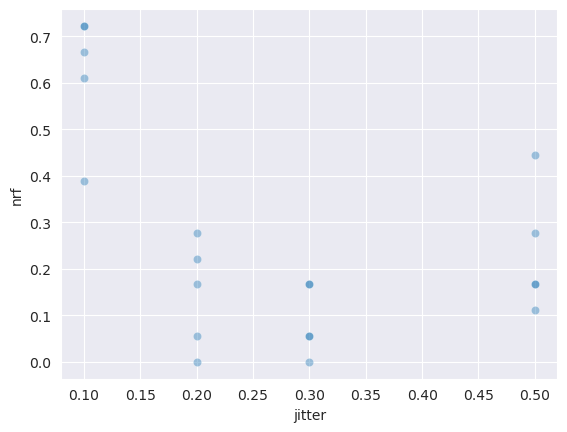

In [49]:
import seaborn as sns

sns.scatterplot(df, x='jitter', y='nrf', alpha=0.4);

In [ ]:
# plot copy numbers
seed = 1
jitter = 0.3



In [51]:
adata.obs_names[0]


'cell_0'

In [54]:
adata['cell_0'].var['chr'].values

array(['1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1',
       '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1',
       '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1',
       '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1',
       '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1',
       '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1',
       '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1',
       '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1',
       '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1',
       '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1',
       '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1',
       '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1',
       '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1',
       '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1

In [60]:
adata['cell_0'].X.flatten().tolist()

[2.0,
 2.0,
 2.0,
 3.0,
 6.0,
 5.0,
 5.0,
 6.0,
 6.0,
 2.0,
 2.0,
 1.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 1.0,
 3.0,
 2.0,
 2.0,
 2.0,
 3.0,
 2.0,
 2.0,
 2.0,
 2.0,
 1.0,
 2.0,
 3.0,
 2.0,
 2.0,
 2.0,
 2.0,
 1.0,
 2.0,
 2.0,
 3.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 4.0,
 3.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 1.0,
 3.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 3.0,
 2.0,
 3.0,
 3.0,
 2.0,
 2.0,
 2.0,
 2.0,
 3.0,
 2.0,
 4.0,
 6.0,
 3.0,
 2.0,
 3.0,
 2.0,
 1.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 1.0,
 2.0,
 3.0,
 4.0,
 3.0,
 2.0,
 2.0,
 2.0,
 2.0,
 3.0,
 2.0,
 2.0,
 2.0,
 2.0,
 1.0,
 2.0,
 2.0,
 2.0,
 4.0,
 4.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 3.0,
 2.0,
 2.0,
 1.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 1.0,
 2.0,
 2.0,
 3.0,
 2.0,
 2.0,
 2.0,
 3.0,
 2.0,
 2.0,
 3.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 1.0,
 2.0,
 2.0,
 3.0,
 3.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 3.0,
 2.0

In [9]:
import io
tnwk = "(((((cell10:29.96379046,(cell21:26.09882052,cell22:49.48840948):8.21997454):34.87911948,cell6:4.13685302):13.28364535,(cell4:96.15982751,cell5:65.32392249):140.82666340):42.67884234,(((((cell11:13.26691031,cell12:30.37063969):25.29146430,(cell14:11.99522057,cell13:21.11747943):2.99280320):65.06888540,(cell7:0.01057409,cell8:16.95998591):12.26235585):48.80884145,((cell15:25.36666977,((cell23:0.00000000,cell34:0.00000000):0.07838536,cell33:72.04650464):89.04249023):207.51135754,((cell16:34.50759386,cell24:42.71765614):4.29591065,(cell35:9.10170530,cell36:34.83942470):36.71628185):70.68750058):134.84617527):5.48046148,((cell17:12.99074149,(cell25:23.03952702,cell26:7.35005298):67.39403351):24.89291041,(cell18:99.95857124,(cell27:1.41283167,cell28:0.00137833):4.69323376):39.20854709):28.12819579):21.33524746):26.93504474,((((cell19:34.42697500,(((((cell37:0.90865695,(cell42:32.35454701,cell43:5.82922299):0.50555805):2.70782045,(((cell45:24.04162690,cell46:13.41421310):338.88795890,cell48:47.76517610):6.68027015,cell47:8.94615735):16.45163424):4.79148886,cell38:65.38257004):12.99032941,(cell41:0.79074670,(cell44:0.33481163,(cell49:30.27048111,cell50:16.70007889):12.39310837):11.93717580):88.81060208):5.36717103,(cell39:3.96610250,cell40:11.55445750):31.38191800):194.26779285):9.61876817,cell20:47.30240249):49.49283530,cell2:46.84455554):88.60535244,((cell29:23.03388555,cell30:11.35089445):31.07716171,((cell3:46.29536011,(cell31:44.17303029,cell32:5.32443971):41.18352489):7.06189097,cell9:10.32288903):12.84924329):26.67668090):212.20431510,cell1:234.49708602);"

true_tree = dendropy.Tree.get(data="(cell1:0.4706572633378211,((((cell2:0.0417198046436599,((cell19:0.01886639810102586,cell20:0.01886639810102586)ancestor25:0.01698376535421976,(((cell37:0.00610721353149229,cell38:0.00610721353149229)ancestor39:0.01653710546478211,((cell42:0.01305417018719175,cell43:0.01305417018719175)ancestor43:0.00760265097867141,((cell45:0.00269426478672601,cell46:0.00269426478672601)ancestor46:0.01368172134962606,(cell47:0.01120965185443665,cell48:0.01120965185443665)ancestor47:0.00516633428191542)ancestor44:0.00428083502951108)ancestor40:0.00198749783041124)ancestor33:0.00929282121531502,((cell39:0.00125417117921771,cell40:0.00125417117921771)ancestor41:0.02823617888239703,(cell41:0.02550120424214689,(cell44:0.00353971109204838,(cell49:0.00086894070385481,cell50:0.00086894070385481)ancestor48:0.00267077038819357)ancestor45:0.02196149315009851)ancestor42:0.00398914581946786)ancestor34:0.00244679014997467)ancestor26:0.00391302324365621)ancestor16:0.00586964118841427)ancestor8:0.08724783737881742,(cell3:0.06912325374923332,(cell9:0.02374867740247489,((cell29:0.00177428806629983,cell30:0.00177428806629983)ancestor35:0.00579548892413252,(cell31:0.00611730835778598,cell32:0.00611730835778598)ancestor36:0.00145246863264636)ancestor27:0.01617890041204255)ancestor17:0.04537457634675843)ancestor9:0.059844388273244)ancestor4:0.03311457455422473,((cell4:0.0016406119398348,cell5:0.0016406119398348)ancestor10:0.15357632528880735,(cell6:0.04059220263834602,(cell10:0.00170934638246032,(cell21:0.00159391820569716,cell22:0.00159391820569716)ancestor28:0.00011542817676316)ancestor18:0.03888285625588569)ancestor11:0.11462473459029615)ancestor5:0.00686527934805989)ancestor2:0.21312597276546633,(((cell7:0.00420510777812492,cell8:0.00420510777812492)ancestor12:0.04115330870147781,((cell11:0.00473005917555261,cell12:0.00473005917555261)ancestor19:0.02901363701866822,(cell13:0.00851980608546802,cell14:0.00851980608546802)ancestor20:0.02522389010875281)ancestor13:0.01161472028538191)ancestor6:0.13452550192561363,(((cell15:0.0108172232377841,(cell23:0.00099813199551739,(cell33:0.00037134275789482,cell34:0.00037134275789482)ancestor37:0.00062678923762257)ancestor29:0.00981909124226671)ancestor21:0.02231782280304519,(cell16:0.02913224753027393,(cell24:0.00937645139881522,(cell35:0.00214934293584118,cell36:0.00214934293584118)ancestor38:0.00722710846297404)ancestor30:0.0197557961314587)ancestor22:0.00400279851055536)ancestor14:0.03634732809816529,((cell17:0.00175078341930094,(cell25:0.00052087140942565,cell26:0.00052087140942565)ancestor31:0.00122991200987529)ancestor23:0.0387203093910032,(cell18:0.00710973369206734,(cell27:0.00397679847960973,cell28:0.00397679847960973)ancestor32:0.00313293521245761)ancestor24:0.0333613591182368)ancestor15:0.02901128132869044)ancestor7:0.11040154426622178)ancestor3:0.195324270936952)ancestor1:0.09544907399565272)founder;", schema='newick')
dpyt = dendropy.Tree.get(data=tnwk, schema='newick', taxon_namespace=true_tree.taxon_namespace)
# dpyt.is_rooted = True
normalized_rf_distance(true_tree, dpyt)




0.22916666666666666